## Load the Car Dataset & Import Important libraries


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/car_pricesDroped.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


## Calculate Basic Statistics

In [ ]:
# Shape of the dataset
print(df.shape)



(472325, 16)


In [ ]:
# Summary statistics for numerical columns
df.describe()


,year,condition,odometer,mmr,sellingprice
count,472325.000000,472325.000000,472325.000000,472325.000000,472325.000000
mean,2010.210980,30.774177,66701.732040,13837.058964,13690.512058
std,3.822151,13.286866,51939.586894,9532.229273,9613.033738
min,1990.000000,1.000000,1.000000,25.000000,1.000000
25%,2008.000000,24.000000,28137.000000,7425.000000,7200.000000
50%,2012.000000,35.000000,51085.000000,12300.000000,12200.000000
75%,2013.000000,41.000000,96590.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
#  Minimum & Maximum selling price
print("Minimum Selling Price:", df['sellingprice'].min())
print("Maximum Selling Price:", df['sellingprice'].max())




Minimum Selling Price: 1.0
Maximum Selling Price: 230000.0


In [ ]:
#Count of unique car conditions:
df['condition'].value_counts()

,count
condition,
19.0,36647
35.0,23209
37.0,22680
44.0,22091
43.0,21593
42.0,21094
36.0,20164
41.0,19889
39.0,17567


In [ ]:
#Missing values check:
df.isnull().sum()

,0
year,0
make,0
model,0
trim,0
body,0
transmission,0
vin,0
state,0
condition,0
odometer,0


###  Feature Understanding**

(Univariate / Bi-variate )



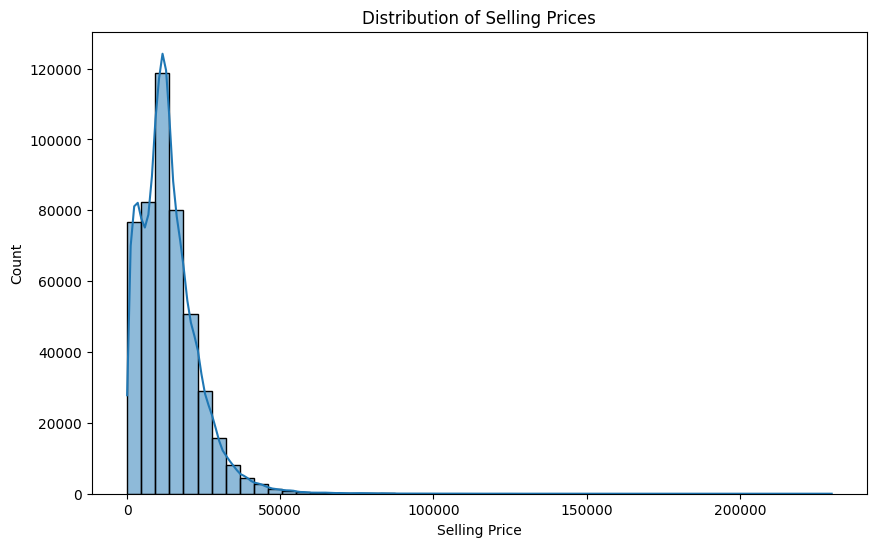

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['sellingprice'], bins=50, kde=True)
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.show()


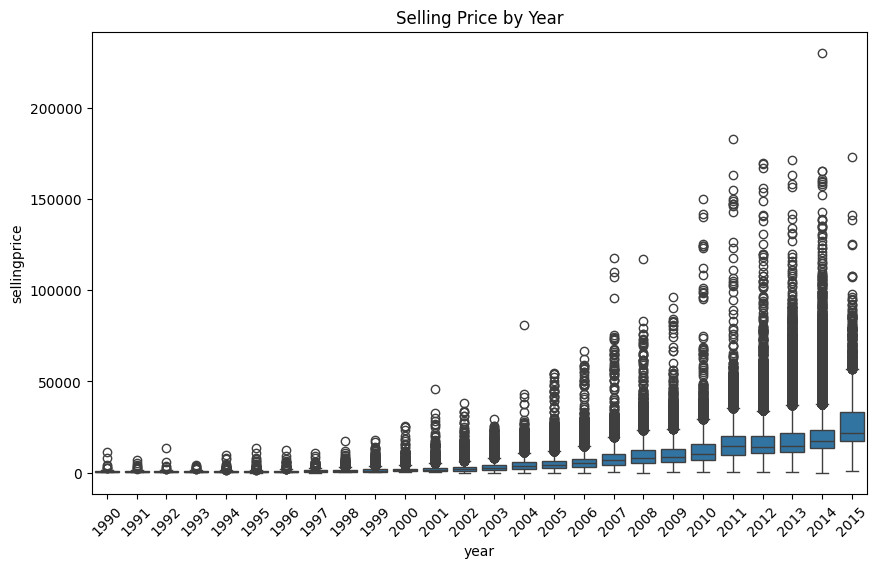

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='year', y='sellingprice', data=df)
plt.xticks(rotation=45)
plt.title('Selling Price by Year')
plt.show()


## Ask Questions About the Data (Hypthesis Testing)



 Do newer cars tend to sell for higher prices?


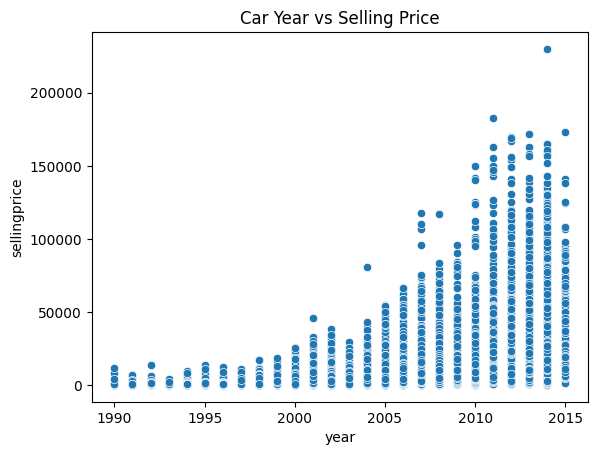

In [ ]:
sns.scatterplot(x='year', y='sellingprice', data=df)
plt.title('Car Year vs Selling Price')
plt.show()

##  Preparee data for ML Model Ingestion











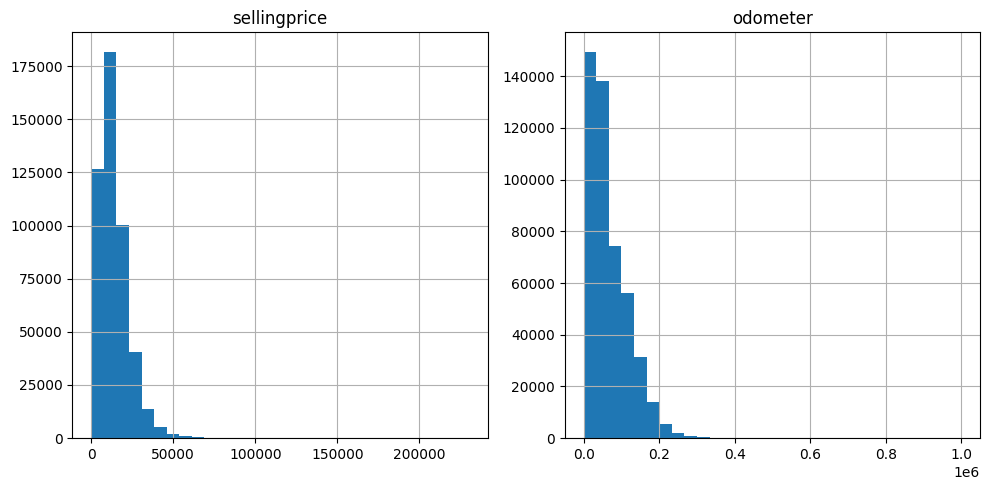

In [ ]:
df[['sellingprice', 'odometer']].hist(bins=30, figsize=(10,5))
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['sellingprice', 'odometer']] = scaler.fit_transform(df[['sellingprice', 'odometer']])
df.head()


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,0.016638,white,black,kia motors america inc,20500.0,0.093474,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,0.009392,white,beige,kia motors america inc,20800.0,0.093474,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,0.001330,gray,black,financial services remarketing (lease),31900.0,0.130431,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,0.014281,white,black,volvo na rep/world omni,27500.0,0.120648,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,0.002640,gray,black,financial services remarketing (lease),66000.0,0.291301,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [ ]:
df.to_csv('car_prices_cleaned.csv', index=False)

In [ ]:

import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


##  Basic Data Profiling


In [ ]:

import pandas as pd

df = pd.read_csv('/content/car_prices.csv')
print(df.shape)

(40076, 16)


In [ ]:

import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
print(df.dtypes)



year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object


In [ ]:
# Missing values
import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
print(df.isnull().sum())

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64


In [ ]:
# Summary statistics
import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
df.describe()

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [ ]:
# Count unique values in a column (e.g., Country)
import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
print(df.nunique())


year                34
make                96
model              973
trim              1963
body                87
transmission         4
vin             550297
state               64
condition           41
odometer        172278
color               46
interior            17
seller           14263
mmr               1101
sellingprice      1887
saledate          3766
dtype: int64


In [ ]:
# Drop rows with missing values
import pandas as pd

df = pd.read_csv('/content/car_prices.csv')
droped=df.dropna()
print(droped)

        year   make                model        trim      body transmission  \
0       2015    Kia              Sorento          LX       SUV    automatic   
1       2015    Kia              Sorento          LX       SUV    automatic   
2       2014    BMW             3 Series  328i SULEV     Sedan    automatic   
3       2015  Volvo                  S60          T5     Sedan    automatic   
4       2014    BMW  6 Series Gran Coupe        650i     Sedan    automatic   
...      ...    ...                  ...         ...       ...          ...   
186158  2006   Ford     F-250 Super Duty      Lariat  Crew Cab    automatic   
186159  2006   Ford              Mustang    Standard     Coupe    automatic   
186160  2006   Ford         Five Hundred     Limited     Sedan    automatic   
186161  2006   Ford     F-250 Super Duty         XLT  SuperCab    automatic   
186162  2006   Ford              Mustang    Standard     Coupe       manual   

                      vin state  condition  odomete

In [ ]:
# Rename columns (example)
import pandas as pd


df = pd.read_csv('/content/car_prices.csv')
df.rename(columns={'car_prices': 'newName'}, inplace=True)

In [ ]:
# Save cleaned dataset
import pandas as pd
df = pd.read_csv('/content/car_prices.csv')
droped=df.dropna()
droped.to_csv('/content/car_pricesDroped.csv', index=False)